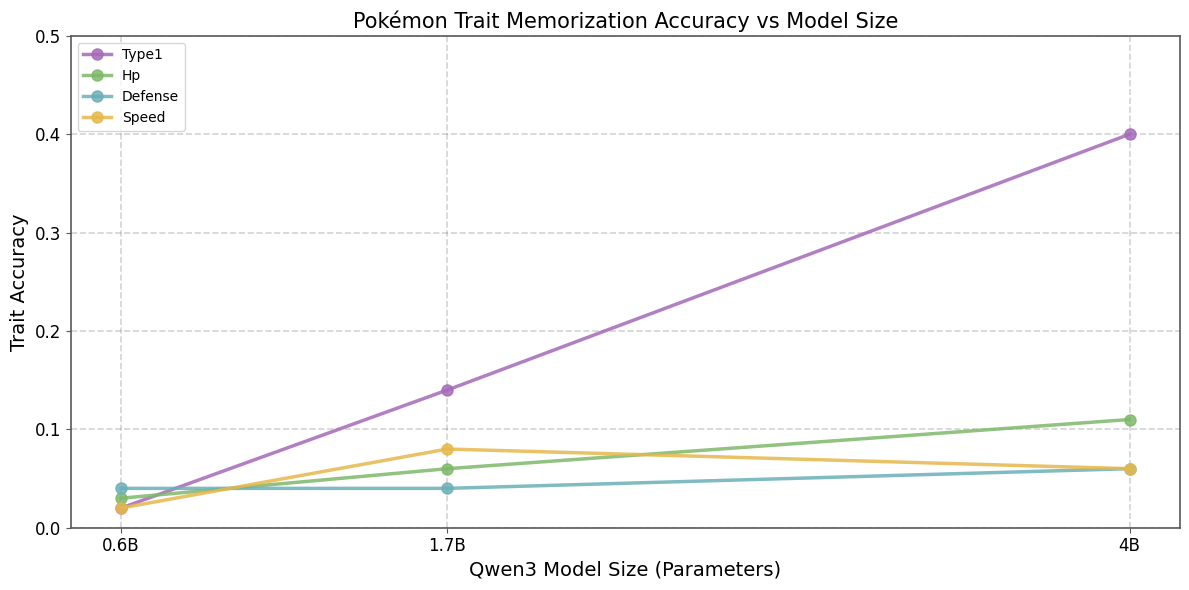

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# ===== Data =====
model_sizes = [0.6, 1.7, 4.0]  # numerical for accurate scaling
model_labels = ["0.6B", "1.7B", "4B"]
traits = ["type1", "hp", "defense", "speed"]
values = {
    "type1": [0.02, 0.14, 0.4],
    "hp": [0.03, 0.06, 0.11],
    "speed": [0.02, 0.08, 0.06],
    "defense": [0.04, 0.04, 0.06],
}

# ===== Style setup (same as before) =====
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Liberation Sans', 'sans-serif'],
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})
_success_color = '#7EB86A'  # green
_fail_color    = '#A56AB8'  # purple
_edge_color    = '#595959'

def _style_axes(ax):
    ax.grid(True, linestyle='--', color='gray', alpha=0.35, linewidth=1.2, zorder=0)
    for side in ['left', 'bottom', 'top', 'right']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color(_edge_color)
        ax.spines[side].set_linewidth(1.2)
    ax.tick_params(axis='both', labelsize=12, color=_edge_color)

def _add_value_labels_line(ax, x, y, fmt='{:.2f}', fontsize=12):
    for xi, yi in zip(x, y):
        ax.text(xi, yi + 0.02, fmt.format(yi), ha='center', va='bottom',
                fontsize=fontsize, color='#1f1f1f', zorder=4)

# ===== Plot setup (line chart) =====
fig, ax = plt.subplots(figsize=(12, 6))
_style_axes(ax)

colors = [_fail_color, _success_color, '#6AAFB8', '#E6B84C']

for i, trait in enumerate(traits):
    y = values[trait]
    ax.plot(model_sizes, y,
            label=trait.capitalize(),
            color=colors[i],
            linewidth=2.5,
            marker='o',
            markersize=8,
            alpha=0.85,
            zorder=3)
    # _add_value_labels_line(ax, model_sizes, y)

# Labels and ticks
ax.set_xticks(model_sizes)
ax.set_xticklabels(model_labels)
ax.set_ylabel("Trait Accuracy")
ax.set_xlabel("Qwen3 Model Size (Parameters)")
ax.set_title("Pokémon Trait Memorization Accuracy vs Model Size")
ax.set_ylim(0, 0.5)

# Legend styling
ax.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig("relationship_p1.pdf")
plt.show()